In [56]:
pip install nbformat

Note: you may need to restart the kernel to use updated packages.


In [57]:
%run DLS_functions+metrics.ipynb

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Imports

In [58]:
import pandas as pd
import os
import csv
from pathlib import Path

# DLS Data

## Round 1

In [59]:
BASE_DIR = os.getcwd()

file_path = os.path.join(
    BASE_DIR,
    "Rawdata",
    "DesignExpert_results_round1_rawdata.csv"
)

df_DE_round1 = pd.read_csv(file_path)

#charg the data usign ";" as delimiter, and it loads it into the list "data"
with open(file_path, newline="", encoding="utf-8") as f:
    reader = csv.reader(f, delimiter=";")
    data = list(reader)

# Stores data
header = data[1]
rows = data[0:]
columns = list(zip(*rows)) #transpses the data (zip(rows)) to convert rows into columns


In [60]:
## Creates Collection
Design_Expert_Sampling_Round1 = Collection("Design_Expert_Sampling_Round1")
print(Design_Expert_Sampling_Round1)

-- Melina DLS Collection --
NAME     : Design_Expert_Sampling_Round1
Experiments : 0



In [61]:
## Creates Experiments. This is the loop that iterates through the columns and adds each experiment to the created collection. 
for col in columns[1:]:
    if col[0] != '': 
        Design_Expert_Sampling_Round1.add_experiment(col[0], debug=0)
print(df_DE_round1)

   SIZE;;AFO-008(2);;;ERM-334(2);;;ERM-335;;;AFO-010;;;AFO-011;;;AFO-012;;;ERM-339;;;ERM-340;;;AFO-015(1);;;AFO-015(2);;;ERM-343;;;ERM-263;;;AFO-018(1);;;AFO-018(2);;;AFO-019;;;ERM-346;;;AFO-021;;;AFO-022;
0   PDI;0.439;0.513;0.529;0.575;0.573;0.553;0.084;...                                                                                                                                                        
1   X Intensity;R1.008(2);R2.008(2);R3.008(2);R1.3...                                                                                                                                                        
2   0.4;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;...                                                                                                                                                        
3   0.463;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;...                                                                                                                           

In [62]:
## Adds Replicas to Corresponding Experiment
# For each column of data, identify the experiment name, replica name, and the data for the x and y axes.
# Then, find the corresponding experiment and add the data to the previously created collection.
for col in columns[1:]:
    exp_name = col[0]
    rep_name = col[2]
    x_data   = columns[0][3:]
    y_data   = col[3:]
    found, experiment = Design_Expert_Sampling_Round1.find_experiment(rep_name, debug=0)
    if found: experiment.add_replica(rep_name, x_data, y_data, debug=0)
    else: print(f"Experiment {col[1]} not found")

### Review data and fitting

In [63]:
## Fitting parameters. These are used to represent the 'ideal' distribution
mu_bounds    = [1.7,4]   ## In logarithmic scale 10^1.7 = 50; 10^4 = 10000
#search for the center of the distribution between 1.7 and 4. The algorithm will only search for results within these limits

for exp in Design_Expert_Sampling_Round1.experiments:
    for rep in exp.replicas:
        rep.fit_data(mu_bounds=mu_bounds, debug=0) # comparison of the real data with an "ideal" distribution and calculation of the distance
        print(exp.name, rep.name, rep.distance)

AFO-008(2) R1.008(2) 0.1476
AFO-008(2) R2.008(2) 0.2872
AFO-008(2) R3.008(2) 0.7821
ERM-334(2) R1.334(2) 0.5515
ERM-334(2) R2.334(2) 0.5455
ERM-334(2) R3.334(2) 0.6776
ERM-335 R1.335 0.2735
ERM-335 R2.335 0.2804
ERM-335 R3.335 0.2719
AFO-010 R1.010 0.1961
AFO-010 R2.010 0.2271
AFO-010 R3.010 0.1995
AFO-011 R1.011 0.2131
AFO-011 R2.011 0.1856
AFO-011 R3.011 0.143
AFO-012 R1.012 0.1059
AFO-012 R2.012 0.1376
AFO-012 R3.012 0.1605
ERM-339 R1.339 0.2281
ERM-339 R2.339 0.2676
ERM-339 R3.339 0.2222
ERM-340 R1.340 0.133
ERM-340 R2.340 0.1072
ERM-340 R3.340 0.1362
AFO-015(1) R1.015(1) 0.183
AFO-015(1) R2.015(1) 0.2322
AFO-015(1) R3.015(1) 0.181
AFO-015(2) R1.015(2) 0.2131
AFO-015(2) R2.015(2) 0.1694
AFO-015(2) R3.015(2) 0.1614
ERM-343 R1.343 35.3803
ERM-343 R2.343 33.7575
ERM-343 R3.343 35.7242
ERM-263 R1.263 0.4077
ERM-263 R2.263 0.3695
ERM-263 R3.263 0.2862
AFO-018(1) R1.018(1) 0.155
AFO-018(1) R2.018(1) 0.1767
AFO-018(1) R3.018(1) 0.215
AFO-018(2) R1.018(2) 0.2513
AFO-018(2) R2.018(2) 0.1755

In [64]:
#Mean distance values of the three replicates of each sample      
for exp in Design_Expert_Sampling_Round1.experiments:
    print(exp.name, exp.distance)

AFO-008(2) 0.4056
ERM-334(2) 0.5915
ERM-335 0.2753
AFO-010 0.2076
AFO-011 0.1806
AFO-012 0.1347
ERM-339 0.2393
ERM-340 0.1255
AFO-015(1) 0.1987
AFO-015(2) 0.1813
ERM-343 34.954
ERM-263 0.3545
AFO-018(1) 0.1822
AFO-018(2) 0.1983
AFO-019 7.2
ERM-346 32.266
AFO-021 25.4875
AFO-022 0.2099


### Plot visualization

True
-- Melina DLS Experiment --
NAME       : ERM-343
CODE       : ERM
NUMBER     : 343
REPLICAS   : 3
COLLECTION : Design_Expert_Sampling_Round1
DISTANCE : 34.954

-- Melina DLS Replica --
NAME       : R1.343
CODE       : R1
NUMBER     : 343
DATA_LEN   : 68
DISTANCE   : 35.3803
EXPERIMENT : ERM-343
COLLECTION : Design_Expert_Sampling_Round1



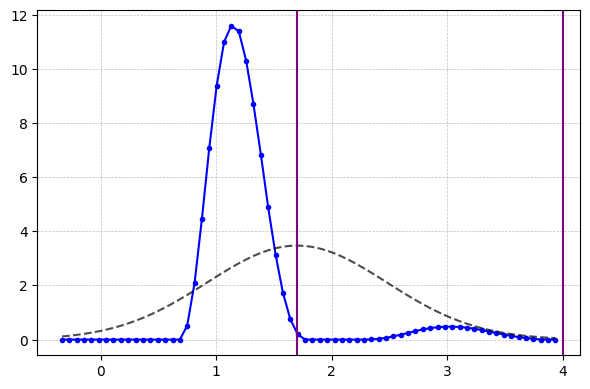

-- Melina DLS Replica --
NAME       : R2.343
CODE       : R2
NUMBER     : 343
DATA_LEN   : 68
DISTANCE   : 33.7575
EXPERIMENT : ERM-343
COLLECTION : Design_Expert_Sampling_Round1



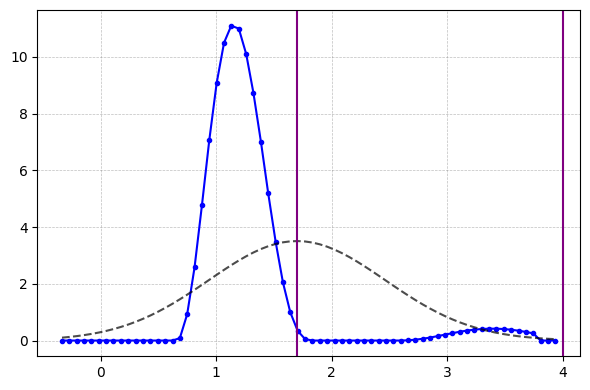

-- Melina DLS Replica --
NAME       : R3.343
CODE       : R3
NUMBER     : 343
DATA_LEN   : 68
DISTANCE   : 35.7242
EXPERIMENT : ERM-343
COLLECTION : Design_Expert_Sampling_Round1



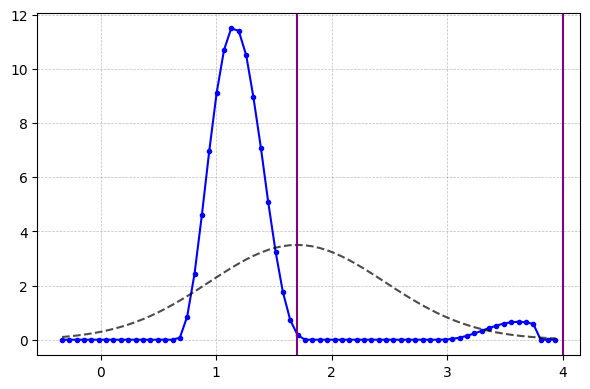

In [65]:
## Visual analysis
# A specific experiment is searched for and executed to generate a plot and see how the data behaves with respect to the ideal

found, debug_exp = Design_Expert_Sampling_Round1.find_experiment("ERM-343")
print(found)
print(debug_exp)

for rep in debug_exp.replicas:
    print(rep)
    rep.plot_fit()

In [66]:
##Saves all the data (complete collection with information of the experiments and replicates) in a .npy file
#save_binary(Design_Expert_Sampling_Round1, "./Design_Expert_Sampling_Round1.npy")

##Loads the data from the .npy file and stores it in a variable if needed
#Design_Expert_Sampling_Round1_loaded = load_binary("./Design_Expert_Sampling_Round1.npy")
#print(Design_Expert_Sampling_Round1)

## Round 2

In [67]:
BASE_DIR = os.getcwd()

file_path = os.path.join(
    BASE_DIR,
    "Rawdata",
    "DesignExpert_results_round2_rawdata.csv"
)

df_DE_round2 = pd.read_csv(file_path)

#charg the data usign ";" as delimiter, and it loads it into the list "data"
with open(file_path, newline="", encoding="utf-8") as f:
    reader = csv.reader(f, delimiter=";")
    data = list(reader)

# Stores data
header = data[1]
rows = data[0:]
columns = list(zip(*rows)) #transpses the data (zip(rows)) to convert rows into columns


In [68]:
## Creates Collection
Design_Expert_Sampling_Round2 = Collection("Design_Expert_Sampling_Round2")
print(Design_Expert_Sampling_Round2)

-- Melina DLS Collection --
NAME     : Design_Expert_Sampling_Round2
Experiments : 0



In [69]:
## Creates Experiments. This is the loop that iterates through the columns and adds each experiment to the created collection. 
for col in columns[1:]:
    if col[0] != '': 
        Design_Expert_Sampling_Round2.add_experiment(col[0], debug=0)
print(df_DE_round2)

   SIZE;;ERM-397(1);;;ERM-397(2);;;ERM-398(1);;;ERM-398(2);;;ERM-399(1);;;ERM-399(2);;;ERM-400;;;ERM-401;;;ERM-402;;;ERM-403;
0   PDI;0.085;0.082;0.082;0.087;0.068;0.071;0.084;...                                                                        
1   X Intensity;R1.397(1);R2.397(1);R3.397(1);R1.3...                                                                        
2   0.4;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;...                                                                        
3   0.463;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;...                                                                        
4   0.536;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;...                                                                        
..                                                ...                                                                        
66  4.80E+03;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0...                                                                 

In [70]:
## Adds Replicas to Corresponding Experiment
# For each column of data, identify the experiment name, replica name, and the data for the x and y axes.
# Then, find the corresponding experiment and add the data to the previously created collection.
for col in columns[1:]:
    exp_name = col[0]
    rep_name = col[2]
    x_data   = columns[0][3:]
    y_data   = col[3:]
    found, experiment = Design_Expert_Sampling_Round2.find_experiment(rep_name, debug=0)
    if found: experiment.add_replica(rep_name, x_data, y_data, debug=0)
    else: print(f"Experiment {col[1]} not found")

### Review data and fitting

In [71]:
## Fitting parameters. These are used to represent the 'ideal' distribution
mu_bounds    = [1.7,4]   ## In logarithmic scale 10^1.7 = 50; 10^4 = 10000
#search for the center of the distribution between 1.7 and 4. The algorithm will only search for results within these limits

for exp in Design_Expert_Sampling_Round2.experiments:
    for rep in exp.replicas:
        rep.fit_data(mu_bounds=mu_bounds, debug=0) # comparison of the real data with an "ideal" distribution and calculation of the distance
        print(exp.name, rep.name, rep.distance)

ERM-397(1) R1.397(1) 0.2368
ERM-397(1) R2.397(1) 0.2416
ERM-397(1) R3.397(1) 0.2163
ERM-397(2) R1.397(2) 0.2163
ERM-397(2) R2.397(2) 0.3069
ERM-397(2) R3.397(2) 0.3085
ERM-398(1) R1.398(1) 0.219
ERM-398(1) R2.398(1) 0.3217
ERM-398(1) R3.398(1) 0.2654
ERM-398(2) R1.398(2) 0.2546
ERM-398(2) R2.398(2) 0.216
ERM-398(2) R3.398(2) 0.2243
ERM-399(1) R1.399(1) 0.3154
ERM-399(1) R2.399(1) 0.21
ERM-399(1) R3.399(1) 0.2677
ERM-399(2) R1.399(2) 0.2292
ERM-399(2) R2.399(2) 0.3085
ERM-399(2) R3.399(2) 0.2349
ERM-400 R1.400 0.2387
ERM-400 R2.400 0.2926
ERM-400 R3.400 0.2551
ERM-401 R1.401 0.2321
ERM-401 R2.401 0.2626
ERM-401 R3.401 0.2457
ERM-402 R1.402 0.1688
ERM-402 R2.402 0.2064
ERM-402 R3.402 0.1702
ERM-403 R1.403 38.4665
ERM-403 R2.403 39.7973
ERM-403 R3.403 33.2916


In [72]:
#Mean distance values of the three replicates of each sample      
for exp in Design_Expert_Sampling_Round2.experiments:
    print(exp.name, exp.distance)

ERM-397(1) 0.2316
ERM-397(2) 0.2772
ERM-398(1) 0.2687
ERM-398(2) 0.2316
ERM-399(1) 0.2644
ERM-399(2) 0.2575
ERM-400 0.2621
ERM-401 0.2468
ERM-402 0.1818
ERM-403 37.1851


### Plot visualization

True
-- Melina DLS Experiment --
NAME       : ERM-403
CODE       : ERM
NUMBER     : 403
REPLICAS   : 3
COLLECTION : Design_Expert_Sampling_Round2
DISTANCE : 37.1851

-- Melina DLS Replica --
NAME       : R1.403
CODE       : R1
NUMBER     : 403
DATA_LEN   : 68
DISTANCE   : 38.4665
EXPERIMENT : ERM-403
COLLECTION : Design_Expert_Sampling_Round2



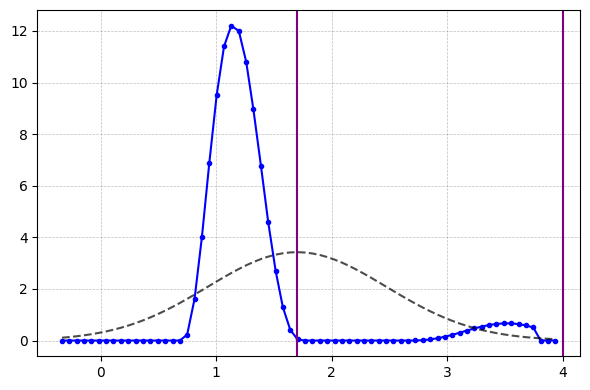

-- Melina DLS Replica --
NAME       : R2.403
CODE       : R2
NUMBER     : 403
DATA_LEN   : 68
DISTANCE   : 39.7973
EXPERIMENT : ERM-403
COLLECTION : Design_Expert_Sampling_Round2



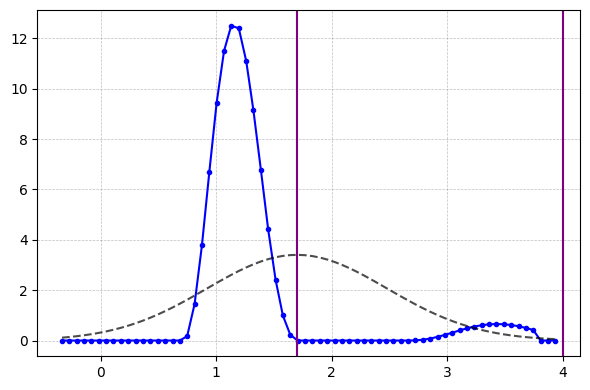

-- Melina DLS Replica --
NAME       : R3.403
CODE       : R3
NUMBER     : 403
DATA_LEN   : 68
DISTANCE   : 33.2916
EXPERIMENT : ERM-403
COLLECTION : Design_Expert_Sampling_Round2



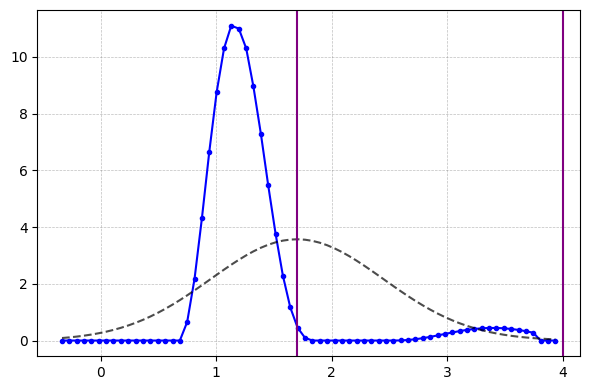

In [73]:
## Visual analysis
# A specific experiment is searched for and executed to generate a plot and see how the data behaves with respect to the ideal

found, debug_exp = Design_Expert_Sampling_Round2.find_experiment("ERM-403")
print(found)
print(debug_exp)

for rep in debug_exp.replicas:
    print(rep)
    rep.plot_fit()

In [74]:
##Saves all the data (complete collection with information of the experiments and replicates) in a .npy file
#save_binary(Design_Expert_Sampling_Round1, "./Design_Expert_Sampling_Round1.npy")

##Loads the data from the .npy file and stores it in a variable if needed
#Design_Expert_Sampling_Round1_loaded = load_binary("./Design_Expert_Sampling_Round1.npy")
#print(Design_Expert_Sampling_Round1)

## Round 3

In [90]:
BASE_DIR = os.getcwd()

file_path = os.path.join(
    BASE_DIR,
    "Rawdata",
    "DesignExpert_results_round3_rawdata.csv"
)

df_DE_round3 = pd.read_csv(file_path)

#charg the data usign ";" as delimiter, and it loads it into the list "data"
with open(file_path, newline="", encoding="utf-8") as f:
    reader = csv.reader(f, delimiter=";")
    data = list(reader)

# Stores data
header = data[1]
rows = data[0:]
columns = list(zip(*rows)) #transpses the data (zip(rows)) to convert rows into columns


In [91]:
## Creates Collection
Design_Expert_Sampling_Round3 = Collection("Design_Expert_Sampling_Round3")
print(Design_Expert_Sampling_Round3)

-- Melina DLS Collection --
NAME     : Design_Expert_Sampling_Round3
Experiments : 0



In [92]:
## Creates Experiments. This is the loop that iterates through the columns and adds each experiment to the created collection. 
for col in columns[1:]:
    if col[0] != '': 
        Design_Expert_Sampling_Round3.add_experiment(col[0], debug=0)
print(df_DE_round3)

   SIZE;;ERM-423;;;ERM-424;;;ERM-425(1);;;ERM-425(2);;;ERM-426;;;ERM-427(1);;;ERM-427(2);;;ERM-428;;;ERM-429(1);;;ERM-429(2);;;ERM-430;;;ERM-431;;;ERM-432(1);;;ERM-432(2);;;ERM-433;
0   PDI;0.08;0.138;0.063;0.03;0.081;0.11;0.077;0.0...                                                                                                                                
1   X Intensity;R1.423;R2.423;R3.423;R1.424;R2.424...                                                                                                                                
2   0.4;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;...                                                                                                                                
3   0.463;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;...                                                                                                                                
4   0.536;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;...                                     

In [93]:
## Adds Replicas to Corresponding Experiment
# For each column of data, identify the experiment name, replica name, and the data for the x and y axes.
# Then, find the corresponding experiment and add the data to the previously created collection.
for col in columns[1:]:
    exp_name = col[0]
    rep_name = col[2]
    x_data   = columns[0][3:]
    y_data   = col[3:]
    found, experiment = Design_Expert_Sampling_Round3.find_experiment(rep_name, debug=0)
    if found: experiment.add_replica(rep_name, x_data, y_data, debug=0)
    else: print(f"Experiment {col[1]} not found")

### Review data and fitting

In [94]:
## Fitting parameters. These are used to represent the 'ideal' distribution
mu_bounds    = [1.7,4]   ## In logarithmic scale 10^1.7 = 50; 10^4 = 10000
#search for the center of the distribution between 1.7 and 4. The algorithm will only search for results within these limits

for exp in Design_Expert_Sampling_Round3.experiments:
    for rep in exp.replicas:
        rep.fit_data(mu_bounds=mu_bounds, debug=0) # comparison of the real data with an "ideal" distribution and calculation of the distance
        print(exp.name, rep.name, rep.distance)

ERM-423 R1.423 0.2666
ERM-423 R2.423 0.1559
ERM-423 R3.423 0.2372
ERM-424 R1.424 0.2829
ERM-424 R2.424 0.2923
ERM-424 R3.424 0.1675
ERM-425(1) R1.425(1) 0.2572
ERM-425(1) R2.425(1) 0.1939
ERM-425(1) R3.425(1) 0.3295
ERM-425(2) R1.425(2) 0.325
ERM-425(2) R2.425(2) 0.307
ERM-425(2) R3.425(2) 0.2343
ERM-426 R1.426 0.2124
ERM-426 R2.426 0.3034
ERM-426 R3.426 0.1988
ERM-427(1) R1.427(1) 0.3504
ERM-427(1) R2.427(1) 0.2977
ERM-427(1) R3.427(1) 0.2062
ERM-427(2) R1.427(2) 0.2874
ERM-427(2) R2.427(2) 0.2767
ERM-427(2) R3.427(2) 0.2275
ERM-428 R1.428 0.2473
ERM-428 R2.428 0.2943
ERM-428 R3.428 0.2382
ERM-429(1) R1.429(1) 0.1872
ERM-429(1) R2.429(1) 0.3019
ERM-429(1) R3.429(1) 0.3737
ERM-429(2) R1.429(2) 0.2494
ERM-429(2) R2.429(2) 0.2594
ERM-429(2) R3.429(2) 0.1587
ERM-430 R1.430 0.1816
ERM-430 R2.430 0.2587
ERM-430 R3.430 0.2591
ERM-431 R1.431 0.9289
ERM-431 R2.431 0.2695
ERM-431 R3.431 0.3914
ERM-432(1) R1.432(1) 7.5328
ERM-432(1) R2.432(1) 8.7221
ERM-432(1) R3.432(1) 5.8442
ERM-432(2) R1.432(

In [95]:
#Mean distance values of the three replicates of each sample      
for exp in Design_Expert_Sampling_Round3.experiments:
    print(exp.name, exp.distance)

ERM-423 0.2199
ERM-424 0.2476
ERM-425(1) 0.2602
ERM-425(2) 0.2888
ERM-426 0.2382
ERM-427(1) 0.2848
ERM-427(2) 0.2639
ERM-428 0.2599
ERM-429(1) 0.2876
ERM-429(2) 0.2225
ERM-430 0.2331
ERM-431 0.5299
ERM-432(1) 7.3664
ERM-432(2) 0.1796
ERM-433 21.1486


### Plot visualization

True
-- Melina DLS Experiment --
NAME       : ERM-433
CODE       : ERM
NUMBER     : 433
REPLICAS   : 3
COLLECTION : Design_Expert_Sampling_Round3
DISTANCE : 21.1486

-- Melina DLS Replica --
NAME       : R1.433
CODE       : R1
NUMBER     : 433
DATA_LEN   : 68
DISTANCE   : 28.4111
EXPERIMENT : ERM-433
COLLECTION : Design_Expert_Sampling_Round3



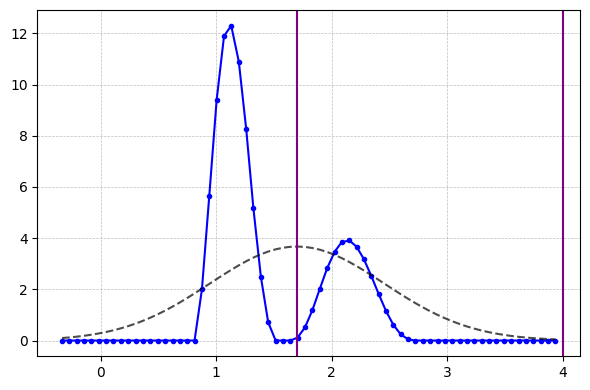

-- Melina DLS Replica --
NAME       : R2.433
CODE       : R2
NUMBER     : 433
DATA_LEN   : 68
DISTANCE   : 24.8428
EXPERIMENT : ERM-433
COLLECTION : Design_Expert_Sampling_Round3



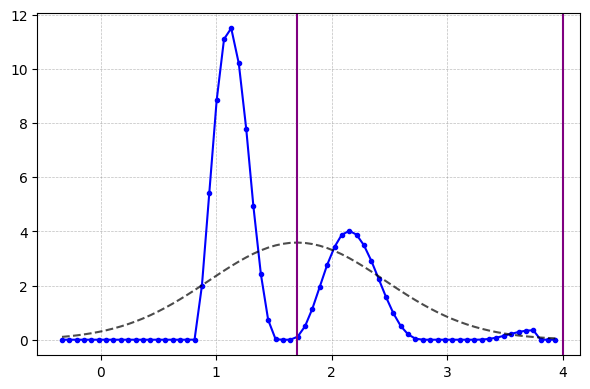

-- Melina DLS Replica --
NAME       : R3.433
CODE       : R3
NUMBER     : 433
DATA_LEN   : 68
DISTANCE   : 10.192
EXPERIMENT : ERM-433
COLLECTION : Design_Expert_Sampling_Round3



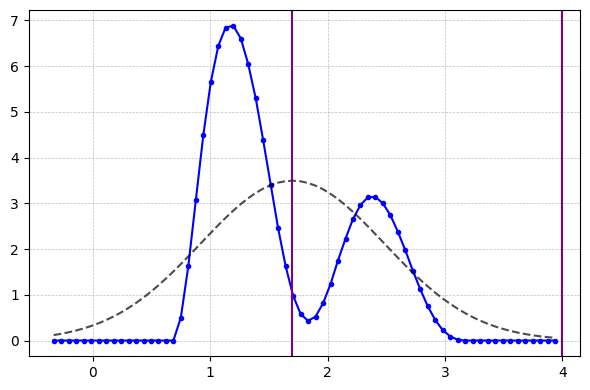

In [97]:
## Visual analysis
# A specific experiment is searched for and executed to generate a plot and see how the data behaves with respect to the ideal

found, debug_exp = Design_Expert_Sampling_Round3.find_experiment("ERM-433")
print(found)
print(debug_exp)

for rep in debug_exp.replicas:
    print(rep)
    rep.plot_fit()

In [83]:
##Saves all the data (complete collection with information of the experiments and replicates) in a .npy file
#save_binary(Design_Expert_Sampling_Round3, "./Design_Expert_Sampling_Round3.npy")

##Loads the data from the .npy file and stores it in a variable if needed
#Design_Expert_Sampling_Round3_loaded = load_binary("./Design_Expert_Sampling_Round3.npy")
#print(Design_Expert_Sampling_Round3)